# MuMax3 Nanotube General Analysis Notebook

Generalised notebook for the **hollow-cylinder (nanotube)** phase-diagram scan.
Set the folder path below and run all cells.

**Output structure expected:**
```
<SIM_DIR>/
  table.txt          (scalar time-series (MuMax3 table))
  m_<iD>_<iH>.ovf    (one spin texture per (Dind, B_rad) point)
```


## 0. Configuration

In [36]:
# Imports
import discretisedfield as df
import ubermagtable as ut
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import glob, os
from matplotlib.ticker import AutoMinorLocator

# Template
plt.style.use('/Users/itxaso/MASTER-codi/2-TFM/MUMAX3/mplstyle/science.mplstyle')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

In [37]:
# ============================================================
#  CONFIGURATION CELL — edit only this cell to switch cases
# ============================================================

import os, glob
import numpy as np

# --- Case registry: add new simulations here ---
CASES = {
    "setA": {
        "sim_dir":        "setA-Cortes-Ortuno/setA.out",
        "field_type":     "axial",          # "axial" | "radial" | "none"
        "N_D":            11,
        "N_H":            11,
        "Msat":           860e3,            # A/m
        "D_max":          3.0e-3,           # J/m²
        "B_max_override": None,             # None --> computed from mu0*Msat
        "description":    "Set A – Cortés-Ortuño, axial field, Dind scan",
    },
    "setA-Hrad": {
        "sim_dir":        "setA-Cortes-Ortuno/setA-Hrad.out",
        "field_type":     "radial",
        "N_D":            11,
        "N_H":            11,
        "Msat":           860e3,
        "D_max":          3.0e-3,
        "B_max_override": None,
        "description":    "Set A – Cortés-Ortuño, radial field (16 sectors), Dind scan",
    },
    "setA-Hrad-2": {
        "sim_dir":        "setA-Cortes-Ortuno/setA-Hrad-2.out",
        "field_type":     "none",           # flower-state test: no H, no D scan
        "N_D":            1,
        "N_H":            1,
        "Msat":           0.384e6,          # A/m  (FeGe, Table 3)
        "D_max":          0.0,              # no DMI in this test
        "B_max_override": 0.0,             # no field in this test
        "description":    "Set A-Hrad-2 – FeGe Table 3, no H, no D --> flower-state test",
    },
}

# -----------------------------------------------
#  SELECT CASE HERE
# -----------------------------------------------
CASE = "setA-Hrad-2"
# -----------------------------------------------

cfg = CASES[CASE]

SIM_DIR          = cfg["sim_dir"]
FIELD_TYPE       = cfg["field_type"]          # "axial" | "radial" | "none"
FIELD_IS_RADIAL  = (FIELD_TYPE == "radial")   # backward-compat flag
N_D              = cfg["N_D"]
N_H              = cfg["N_H"]
Msat             = cfg["Msat"]
D_max            = cfg["D_max"]
mu0              = 4 * np.pi * 1e-7
B_max            = cfg["B_max_override"] if cfg["B_max_override"] is not None else mu0 * Msat

D_vals = np.linspace(0, D_max, N_D)
B_vals = np.linspace(0, B_max, N_H)

PLOTS_DIR = os.path.join(SIM_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Field axis label
B_LABEL = {
    "axial":  r"$B_z$ (mT)",
    "radial": r"$B_\mathrm{rad}$ (mT)",
    "none":   r"$B$ (mT)",
}[FIELD_TYPE]

# Search for snapshots
ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, "m*.ovf")))

print(f"Case        : {CASE}")
print(f"Description : {cfg['description']}")
print(f"Folder      : {SIM_DIR}")
print(f"Plots folder: {PLOTS_DIR}")
print(f"Field type  : {FIELD_TYPE}")
print(f"Grid scan   : N_D={N_D}, N_H={N_H}  (expected {N_D*N_H} snapshots)")
print(f"D range     : 0 --> {D_max*1e3:.2f} mJ/m²")
print(f"B range     : 0 --> {B_max*1e3:.2f} mT")
print(f"Snapshots   : {len(ovf_files)} found")

if ovf_files:
    import discretisedfield as df
    sample = df.Field.from_file(ovf_files[0])
    print(f"Grid        : {sample.mesh.n}")
    print(f"Cell (nm)   : {np.array(sample.mesh.cell)*1e9}")
    print(f"Region (nm) : {np.array(sample.mesh.region.pmin)*1e9}  -->  {np.array(sample.mesh.region.pmax)*1e9}")

Case        : setA-Hrad-2
Description : Set A-Hrad-2 – FeGe Table 3, no H, no D --> flower-state test
Folder      : setA-Cortes-Ortuno/setA-Hrad-2.out
Plots folder: setA-Cortes-Ortuno/setA-Hrad-2.out/plots
Field type  : none
Grid scan   : N_D=1, N_H=1  (expected 1 snapshots)
D range     : 0 --> 0.00 mJ/m²
B range     : 0 --> 0.00 mT
Snapshots   : 2 found
Grid        : [96 96 32]
Cell (nm)   : [1. 1. 1.]
Region (nm) : [0. 0. 0.]  -->  [96. 96. 32.]


In [38]:
# --- ONLY EDIT THIS CELL TO SWITCH BETWEEN CASES ---

CASE = "setA-Hrad-2"          # options: "setA" or "setA-Hrad" or other

if CASE == "setA":
    SIM_DIR = "setA-Cortes-Ortuno/setA.out"
    FIELD_IS_RADIAL = False
elif CASE == "setA-Hrad":
    SIM_DIR = "setA-Cortes-Ortuno/setA-Hrad.out"
    FIELD_IS_RADIAL = True
elif CASE == "setA-Hrad-2":
    SIM_DIR = "setA-Cortes-Ortuno/setA-Hrad-2.out"
    FIELD_IS_RADIAL = True
#else:
#    raise ValueError("CASE must be 'setA' or 'setA-Hrad'.")

PLOTS_DIR = os.path.join(SIM_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Scan parameters
N_D = 11
N_H = 11

# Physical scan parameters
Ms = 860e3          # A/m
D_max = 3.0e-3      # J/m^2
mu0 = 4 * np.pi * 1e-7
B_max = mu0 * Ms

# Derived scan axes
D_vals = np.linspace(0, D_max, N_D)
B_vals = np.linspace(0, B_max, N_H)

# Label that adapts to the case
B_label = r"$B_{m rad}$ (mT)" if FIELD_IS_RADIAL else r"$B_z$ (mT)"

# Search the snapshots
ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, "m_*.ovf")))
print(f"Folder : {SIM_DIR}")
print(f"Plots folder : {PLOTS_DIR}")
print(f"Field type : {'radial' if FIELD_IS_RADIAL else 'axial'}")
print(f"Snapshots found: {len(ovf_files)} (expected {N_D*N_H})")

if ovf_files:
    sample = df.Field.from_file(ovf_files[0])
    print(f"Grid : {sample.mesh.n}")
    print(f"Cell : {np.array(sample.mesh.cell)*1e9} nm")
    print(f"Region : {np.array(sample.mesh.region.pmin)*1e9} --> {np.array(sample.mesh.region.pmax)*1e9} nm")


Folder : setA-Cortes-Ortuno/setA-Hrad-2.out
Plots folder : setA-Cortes-Ortuno/setA-Hrad-2.out/plots
Field type : radial
Snapshots found: 0 (expected 121)


## 1. Scalar table (averages vs scan index)

In [39]:
table = ut.Table.fromfile(os.path.join(SIM_DIR, 'table.txt'))
print(table.data.columns.tolist())
table.data.head()

['t', 'mx', 'my', 'mz', 'Dbulk']


,t,mx,my,mz,Dbulk
0,0.0,0.000802,0.001882,-0.005781,0.0


## 2. Phase diagram of m components in the (D, B) plane

Reshape the scalar table into an N_D × N_H grid.

The scan loops outer=iD, inner=iH.


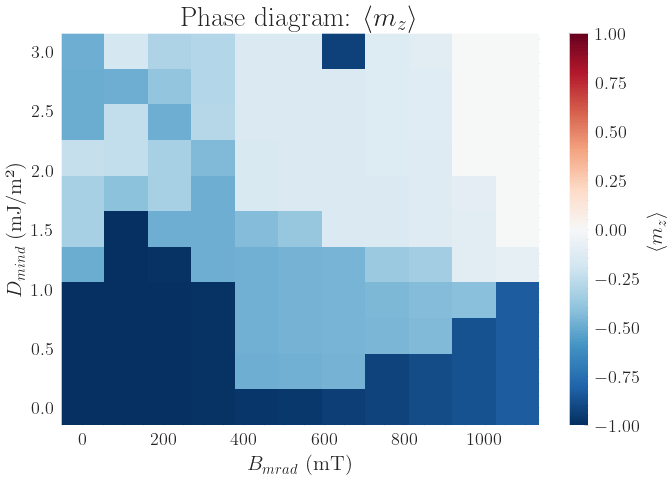

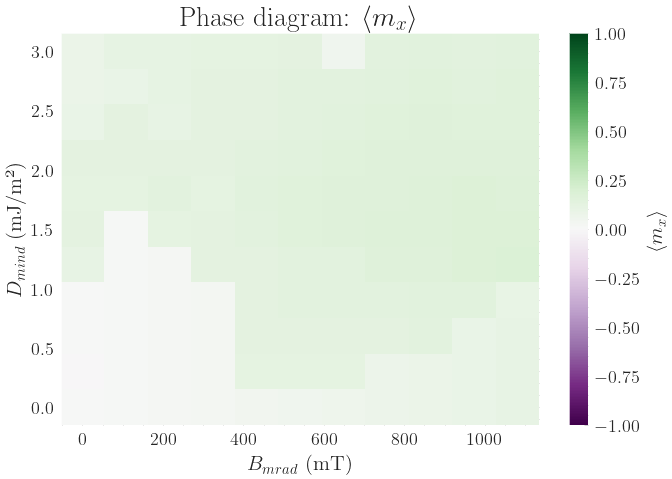

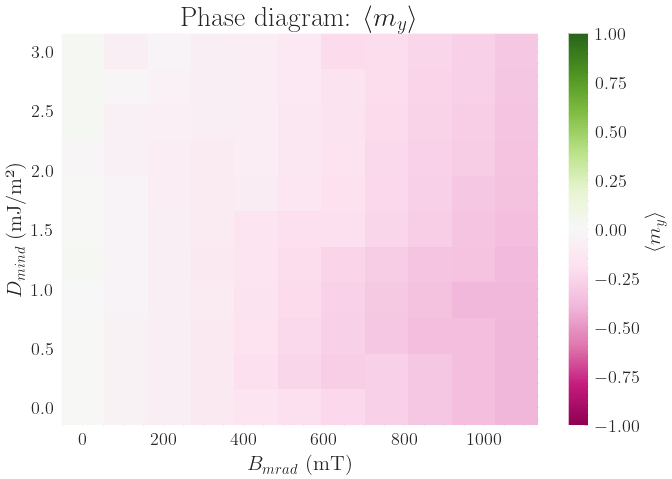

In [4]:
# Use the analytically reconstructed axes from the Configuration cell.
# This works for both setA (axial) and setA-Hrad (radial).

mz_flat = table.data["mz"].values[:N_D * N_H]
mx_flat = table.data["mx"].values[:N_D * N_H]
my_flat = table.data["my"].values[:N_D * N_H]

MZ = mz_flat.reshape(N_D, N_H)
MX = mx_flat.reshape(N_D, N_H)
MY = my_flat.reshape(N_D, N_H)

def plot_phase_grid(M, title, cbar_label, cmap, savename):
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.pcolormesh(B_vals * 1e3, D_vals * 1e3, M,
                       cmap=cmap, vmin=-1, vmax=1, shading="auto")
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_xlabel(B_label)
    ax.set_ylabel(r"$D_{m ind}$ (mJ/m²)")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, savename), dpi=150, bbox_inches="tight")
    plt.show()

plot_phase_grid(MZ, r"Phase diagram: $\langle m_z \rangle$", r"$\langle m_z \rangle$", "RdBu_r", "phase_diagram_mz.pdf")
plot_phase_grid(MX, r"Phase diagram: $\langle m_x \rangle$", r"$\langle m_x \rangle$", "PRGn", "phase_diagram_mx.pdf")
plot_phase_grid(MY, r"Phase diagram: $\langle m_y \rangle$", r"$\langle m_y \rangle$", "PiYG", "phase_diagram_my.pdf")


## 3. Single snapshot — cross-sections

Pick any `(iD, iH)` point and inspect it in detail.


### General case

Loaded : setA-Cortes-Ortuno/setA-Hrad-2.out/m000001.ovf
Grid   : [96 96 96]
Cell   : [1. 1. 1.] nm


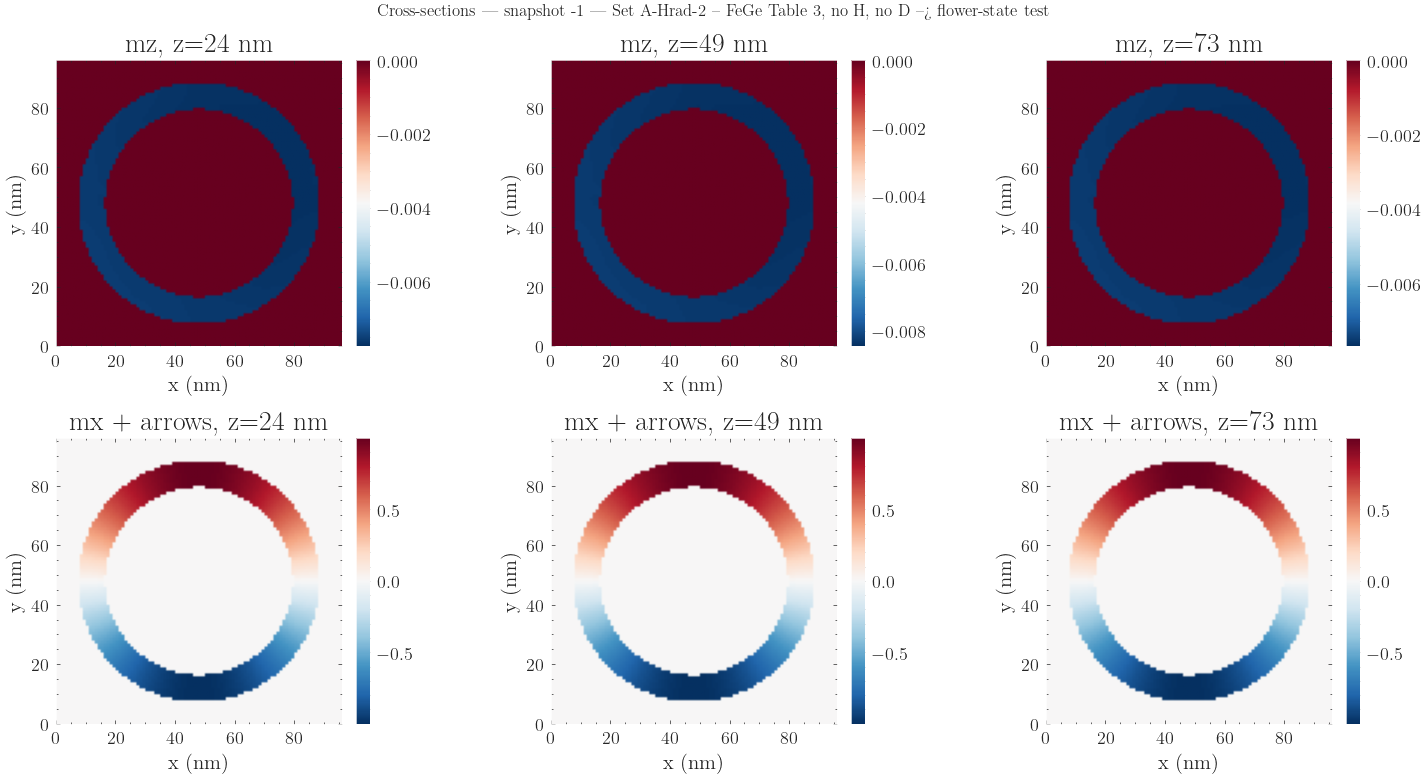

In [10]:
# ── Choose snapshot ──────────────────────────────────────────────
# For scan cases (setA, setA-Hrad): set iD_plot and iH_plot
# For single-run cases (setA-Hrad-2): set snapshot_index (0 = first, -1 = last/final)

iD_plot        = 0    # ignored for single-run cases
iH_plot        = 0    # ignored for single-run cases
snapshot_index = -1   # -1 = last saved snapshot (final relaxed state)

# ── Load the right file ───────────────────────────────────────────
if N_D > 1 or N_H > 1:
    # Scan case: filename encodes (iD, iH)
    fname = os.path.join(SIM_DIR, f'm_{iD_plot}_{iH_plot}.ovf')
    title_str = (f'iD={iD_plot} ({D_vals[iD_plot]*1e3:.1f} mJ/m²), '
                 f'iH={iH_plot} ({B_vals[iH_plot]*1e3:.1f} mT)')
else:
    # Single-run case: pick by index from sorted autosave list
    fname = ovf_files[snapshot_index]
    title_str = f'snapshot {snapshot_index} — {cfg["description"]}'

field = df.Field.from_file(fname)
print(f'Loaded : {fname}')
print(f'Grid   : {field.mesh.n}')
print(f'Cell   : {np.array(field.mesh.cell)*1e9} nm')

# ── Cross-sections along z ────────────────────────────────────────
Nz = field.mesh.n[2]
z_indices = [Nz // 4, Nz // 2, 3 * Nz // 4]
z_coords  = [field.mesh.region.pmin[2] + (i + 0.5) * field.mesh.cell[2]
             for i in z_indices]

fig, axes = plt.subplots(2, len(z_indices), figsize=(5 * len(z_indices), 8))

for col, (iz, zc) in enumerate(zip(z_indices, z_coords)):
    # top row: mz colourmap
    field.sel(z=zc).z.mpl.scalar(ax=axes[0][col], cmap='RdBu_r', colorbar=True)
    axes[0][col].set_title(f'mz,  z={zc*1e9:.0f} nm')

    # bottom row: mx 
    field.sel(z=zc).x.mpl.scalar(ax=axes[1][col], cmap='RdBu_r', colorbar=True)
    axes[1][col].set_title(f'mx,  z={zc*1e9:.0f} nm')

plt.suptitle(f'Cross-sections: {title_str}', fontsize=12)
plt.tight_layout()

# Save with a name that works for both scan and single-run
save_tag = f'{iD_plot}_{iH_plot}' if (N_D > 1 or N_H > 1) else f'snap{snapshot_index}'
plt.savefig(os.path.join(PLOTS_DIR, f'cross_sections_{save_tag}.pdf'),
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Choose the snapshot
iD_plot = 0  # D index (0 .. N_D-1)
iH_plot = 10  # B index (0 .. N_H-1)

fname = os.path.join(SIM_DIR, f'm_{iD_plot}_{iH_plot}.ovf')
field = df.Field.from_file(fname)
print(f'Loaded: {fname}')
print(f'D = {D_vals[iD_plot]*1e3:.2f} mJ/m², B = {B_vals[iH_plot]*1e3:.1f} mT')

# Cross-sections along z
Nz = field.mesh.n[2]
z_indices = [Nz // 4, Nz // 2, 3 * Nz // 4]
z_coords = [field.mesh.region.pmin[2] + (i + 0.5) * field.mesh.cell[2]
            for i in z_indices]

fig, axes = plt.subplots(2, len(z_indices), figsize=(5 * len(z_indices), 8))
for col, (iz, zc) in enumerate(zip(z_indices, z_coords)):

    # top row: mz colourmap
    field.sel(z=zc).z.mpl.scalar(ax=axes[0][col], cmap='RdBu_r', colorbar=True)
    axes[0][col].set_title(f'mz, z={zc*1e9:.0f} nm')

    # bottom row: mx + arrows
    field.sel(z=zc).x.mpl.scalar(ax=axes[1][col], cmap='RdBu_r', colorbar=True)
    field.sel(z=zc).resample(n=(12, 12)).mpl.vector(
        ax=axes[1][col], use_color=False, color='black')
    axes[1][col].set_title(f'mx + arrows, z={zc*1e9:.0f} nm')

plt.suptitle(
    f'Cross-sections — iD={iD_plot} ({D_vals[iD_plot]*1e3:.1f} mJ/m²), '
    f'iH={iH_plot} ({B_vals[iH_plot]*1e3:.1f} mT)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'cross_sections_{iD_plot}_{iH_plot}.pdf'), dpi=150, bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'setA-Cortes-Ortuno/setA-Hrad-2.out/m_*.ovf'

## 4. Longitudinal slice (xz plane at y ≈ 0)

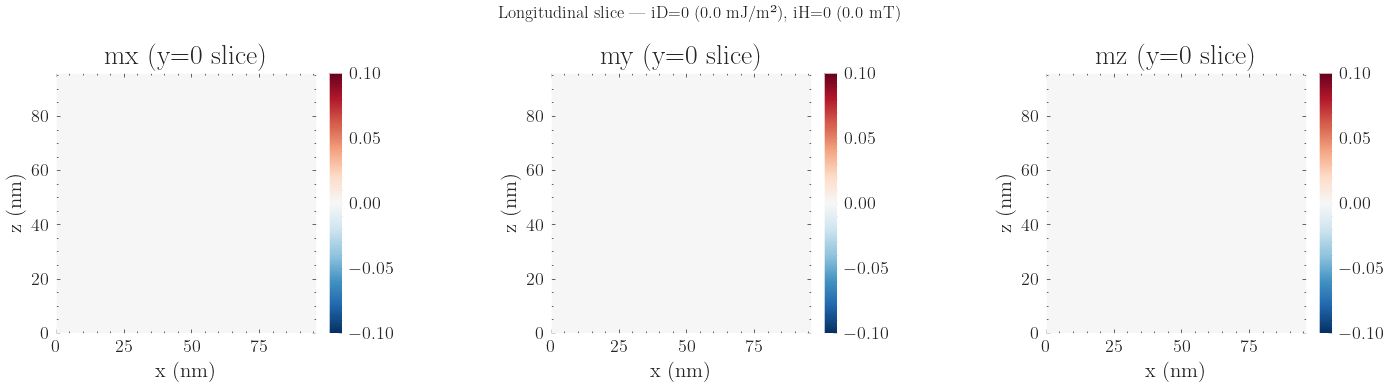

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
y_mid = 0.0
for ax, comp in zip(axes, ['x', 'y', 'z']):
    getattr(field.sel(y=y_mid), comp).mpl.scalar(
        ax=ax, cmap='RdBu_r', colorbar=True)
    ax.set_title(f'm{comp} (y=0 slice)')
plt.suptitle(
    f'Longitudinal slice — iD={iD_plot} ({D_vals[iD_plot]*1e3:.1f} mJ/m²), '
    f'iH={iH_plot} ({B_vals[iH_plot]*1e3:.1f} mT)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'longitudinal_{iD_plot}_{iH_plot}.pdf'), dpi=150, bbox_inches='tight')
plt.show()


## 5. 3D interactive (k3d)

In [15]:
# ============================================================
#  3D INTERACTIVE SPIN VIEWER
# ============================================================
import k3d
import numpy as np
import discretisedfield as df

# --- pick which snapshot to visualise ---
iD = 0
iH = 0
snap_index = iD * N_H + iH

if not ovf_files:
    raise FileNotFoundError(f"No .ovf snapshots found in {SIM_DIR}")
if snap_index >= len(ovf_files):
    raise IndexError(f"snap_index={snap_index} out of range ({len(ovf_files)} snapshots found). Adjust iD/iH.")

ovf_path = ovf_files[snap_index]
field = df.Field.from_file(ovf_path)

print(f"Visualising : {os.path.basename(ovf_path)}")
print(f"  iD={iD}  D = {D_vals[iD]*1e3:.3f} mJ/m²")
print(f"  iH={iH}  B = {B_vals[iH]*1e3:.3f} mT")
print(f"  Grid: {field.mesh.n}  |  Cell: {np.array(field.mesh.cell)*1e9} nm")

# --- 3D interactive plot: vectors coloured by mz ---
field.orientation.k3d.vector(color_field=field.z)

Visualising : m000000.ovf
  iD=0  D = 0.000 mJ/m²
  iH=0  B = 0.000 mT
  Grid: [96 96 96]  |  Cell: [1. 1. 1.] nm


Output()

KeyboardInterrupt: 

In [12]:
try:
    import k3d
    field.x.k3d.scalar(filter_field=field.norm)
except ImportError:
    print('k3d not installed — run:  pip install k3d')


Output()

KeyboardInterrupt: 

In [9]:
# list all saved magnetisation files
ovf_files_list = sorted([f for f in os.listdir(SIM_DIR) if f.endswith(".ovf")])
print(ovf_files_list)

# pick ONE snapshot by (iD, iH) index
iD, iH = 5, 3
filename = f"m_{iD}_{iH}.ovf"
field = df.Field.from_file(os.path.join(SIM_DIR, filename))
print(f"Loaded: {filename} | grid: {field.mesh.n}")
print(f"D = {D_vals[iD]*1e3:.2f} mJ/m², B = {B_vals[iH]*1e3:.1f} mT")


['m_0_0.ovf', 'm_0_1.ovf', 'm_0_10.ovf', 'm_0_2.ovf', 'm_0_3.ovf', 'm_0_4.ovf', 'm_0_5.ovf', 'm_0_6.ovf', 'm_0_7.ovf', 'm_0_8.ovf', 'm_0_9.ovf', 'm_10_0.ovf', 'm_10_1.ovf', 'm_10_10.ovf', 'm_10_2.ovf', 'm_10_3.ovf', 'm_10_4.ovf', 'm_10_5.ovf', 'm_10_6.ovf', 'm_10_7.ovf', 'm_10_8.ovf', 'm_10_9.ovf', 'm_1_0.ovf', 'm_1_1.ovf', 'm_1_10.ovf', 'm_1_2.ovf', 'm_1_3.ovf', 'm_1_4.ovf', 'm_1_5.ovf', 'm_1_6.ovf', 'm_1_7.ovf', 'm_1_8.ovf', 'm_1_9.ovf', 'm_2_0.ovf', 'm_2_1.ovf', 'm_2_10.ovf', 'm_2_2.ovf', 'm_2_3.ovf', 'm_2_4.ovf', 'm_2_5.ovf', 'm_2_6.ovf', 'm_2_7.ovf', 'm_2_8.ovf', 'm_2_9.ovf', 'm_3_0.ovf', 'm_3_1.ovf', 'm_3_10.ovf', 'm_3_2.ovf', 'm_3_3.ovf', 'm_3_4.ovf', 'm_3_5.ovf', 'm_3_6.ovf', 'm_3_7.ovf', 'm_3_8.ovf', 'm_3_9.ovf', 'm_4_0.ovf', 'm_4_1.ovf', 'm_4_10.ovf', 'm_4_2.ovf', 'm_4_3.ovf', 'm_4_4.ovf', 'm_4_5.ovf', 'm_4_6.ovf', 'm_4_7.ovf', 'm_4_8.ovf', 'm_4_9.ovf', 'm_5_0.ovf', 'm_5_1.ovf', 'm_5_10.ovf', 'm_5_2.ovf', 'm_5_3.ovf', 'm_5_4.ovf', 'm_5_5.ovf', 'm_5_6.ovf', 'm_5_7.ovf', 'm_5_8

In [ ]:
import k3d

plot = k3d.plot()

# scalar: mz coloured by norm, masked to magnetic region
field.z.k3d.scalar(
    filter_field=field.norm,  # hides vacuum cells
    # plot=plot,
    # color_map='RdBu',
    # name=f"mz [{filename}]"
)

# overlay: arrows showing full m vector (subsample to keep it fast)
# field.k3d.vector(
#     filter_field=field.norm,
#     plot=plot,
#     head_size=2.0,
#     scale=2e-9,
#     name="m vectors"
# )

plot.display()


In [ ]:
import k3d
import numpy as np
import time

iD_fixed = 5

snapshots = []
labels = []
for iH in range(N_H):
    fname = os.path.join(SIM_DIR, f"m_{iD_fixed}_{iH}.ovf")
    if os.path.exists(fname):
        snapshots.append(df.Field.from_file(fname))
        labels.append(
            f"iD={iD_fixed} ({D_vals[iD_fixed]*1e3:.1f} mJ/m²) "
            f"iH={iH} ({B_vals[iH]*1e3:.1f} mT)"
        )

print(f"Loaded {len(snapshots)} snapshots")

plot = k3d.plot()
arrays = [s.z.array.astype(np.float32) for s in snapshots]

vol = k3d.volume(
    arrays[0],
    color_range=[-1, 1],
    alpha_coef=50,
    name=labels[0]
)
plot += vol
plot.display()

for i, arr in enumerate(arrays):
    vol.volume = arr
    vol.name = labels[i]
    time.sleep(0.8)


In [ ]:
import ipywidgets as widgets
from IPython.display import display

plot = k3d.plot()
vol  = k3d.volume(
    arrays[0],
    #color_map=k3d.colormaps.matplotlib_color_maps.RdBu,
    color_range=[-1, 1],
    alpha_coef=50
)
plot += vol
plot.display()

slider = widgets.IntSlider(value=0, min=0, max=len(arrays)-1,
                           description='iH frame:')
label  = widgets.Label(value=labels[0])

def update(change):
    i = change['new']
    vol.volume = arrays[i]
    label.value = labels[i]

slider.observe(update, names='value')
display(widgets.HBox([slider, label]))

## 6. Azimuthal spin profile: ring at mid-z

Sample the magnetisation on a circle at `r_sample` and `z_mid`.


NameError: name 'iD_plot' is not defined

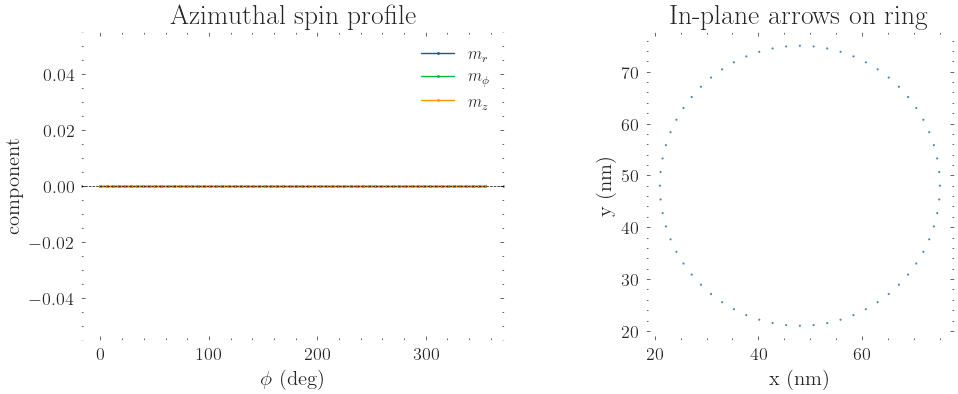

In [10]:
# Geometry (must match your .mx3)
R_sample = 27e-9  # m — mid-shell radius (R_in + R_out) / 2
N_phi = 64  # number of azimuthal sample points

cx = (field.mesh.region.pmin[0] + field.mesh.region.pmax[0]) / 2
cy = (field.mesh.region.pmin[1] + field.mesh.region.pmax[1]) / 2
cz = (field.mesh.region.pmin[2] + field.mesh.region.pmax[2]) / 2

phi = np.linspace(0, 2 * np.pi, N_phi, endpoint=False)
xs = cx + R_sample * np.cos(phi)
ys = cy + R_sample * np.sin(phi)
z_mid = cz

mx_ring = [field((x, y, z_mid))[0] for x, y in zip(xs, ys)]
my_ring = [field((x, y, z_mid))[1] for x, y in zip(xs, ys)]
mz_ring = [field((x, y, z_mid))[2] for x, y in zip(xs, ys)]

# Radial and tangential components
mr = [mx * np.cos(p) + my * np.sin(p)
      for mx, my, p in zip(mx_ring, my_ring, phi)]
mphi = [-mx * np.sin(p) + my * np.cos(p)
        for mx, my, p in zip(mx_ring, my_ring, phi)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
phi_deg = np.degrees(phi)
axes[0].plot(phi_deg, mr, label=r'$m_r$')
axes[0].plot(phi_deg, mphi, label=r'$m_\phi$')
axes[0].plot(phi_deg, mz_ring, label=r'$m_z$')
axes[0].set_xlabel(r'$\phi$ (deg)')
axes[0].set_ylabel('component')
axes[0].set_title('Azimuthal spin profile')
axes[0].legend()
axes[0].axhline(0, color='k', lw=0.5, ls='--')

axes[1].quiver(xs * 1e9, ys * 1e9, mx_ring, my_ring,
               scale=15, color='steelblue')
axes[1].set_xlabel('x (nm)')
axes[1].set_ylabel('y (nm)')
axes[1].set_title('In-plane arrows on ring')
axes[1].set_aspect('equal')

plt.suptitle(
    f'Azimuthal profile: iD={iD_plot} ({D_vals[iD_plot]*1e3:.1f} mJ/m²), '
    f'iH={iH_plot} ({B_vals[iH_plot]*1e3:.1f} mT)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'azimuthal_{iD_plot}_{iH_plot}.pdf'), dpi=150, bbox_inches='tight')
plt.show()


#### Plot for one specific file

##### single OVF file

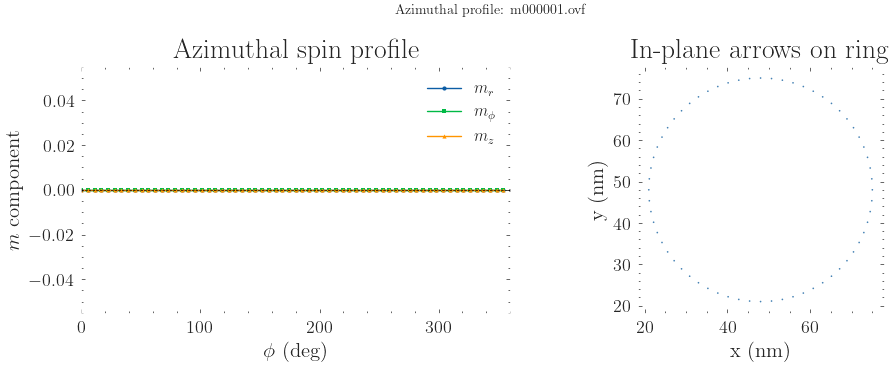

Saved azimuthal_m000001.pdf


In [ ]:
OVF_FILE = "/Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/m000001.ovf"   # ← change this

# --- Geometry (mid-shell ring) ---
R_sample = 27e-9   # m  — (R_in + R_out) / 2 of your nanotube
N_phi    = 64      # azimuthal sample points

# ── load field ────────────────────────────────────────────────────────────────
field = df.Field.from_file(OVF_FILE)

# ── ring coordinates ──────────────────────────────────────────────────────────
cx = (field.mesh.region.pmin[0] + field.mesh.region.pmax[0]) / 2
cy = (field.mesh.region.pmin[1] + field.mesh.region.pmax[1]) / 2
cz = (field.mesh.region.pmin[2] + field.mesh.region.pmax[2]) / 2

phi  = np.linspace(0, 2 * np.pi, N_phi, endpoint=False)
xs   = cx + R_sample * np.cos(phi)
ys   = cy + R_sample * np.sin(phi)

mx_ring = [field((x, y, cz))[0] for x, y in zip(xs, ys)]
my_ring = [field((x, y, cz))[1] for x, y in zip(xs, ys)]
mz_ring = [field((x, y, cz))[2] for x, y in zip(xs, ys)]

# ── cylindrical decomposition ─────────────────────────────────────────────────
mr   = [ mx * np.cos(p) + my * np.sin(p)  for mx, my, p in zip(mx_ring, my_ring, phi)]
mphi = [-mx * np.sin(p) + my * np.cos(p)  for mx, my, p in zip(mx_ring, my_ring, phi)]

# ── plot ──────────────────────────────────────────────────────────────────────
phi_deg = np.degrees(phi)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# --- left panel: component profiles ---
ax = axes[0]
ax.plot(phi_deg, mr,      'o-', ms=3, label=r'$m_r$')
ax.plot(phi_deg, mphi,    's-', ms=3, label=r'$m_\phi$')
ax.plot(phi_deg, mz_ring, '^-', ms=3, label=r'$m_z$')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(r'$\phi$ (deg)')
ax.set_ylabel(r'$m$ component')
ax.set_title('Azimuthal spin profile')
ax.set_xlim(0, 360)
ax.grid(alpha=0.25)
ax.legend(frameon=False)

# --- right panel: in-plane arrows ---
ax = axes[1]
ax.quiver(np.array(xs) * 1e9, np.array(ys) * 1e9,
          mx_ring, my_ring,
          scale=15, color='steelblue')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')
ax.set_title('In-plane arrows on ring')
ax.set_aspect('equal')
ax.grid(alpha=0.25)

# ── suptitle & save ───────────────────────────────────────────────────────────
plt.suptitle(
    f'Azimuthal profile: {os.path.basename(OVF_FILE)}',
    fontsize=10
)
plt.tight_layout()

savename = f'azimuthal_{os.path.splitext(os.path.basename(OVF_FILE))[0]}.pdf'
plt.savefig(os.path.join(PLOTS_DIR, savename), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {savename}')

##### single TXT file

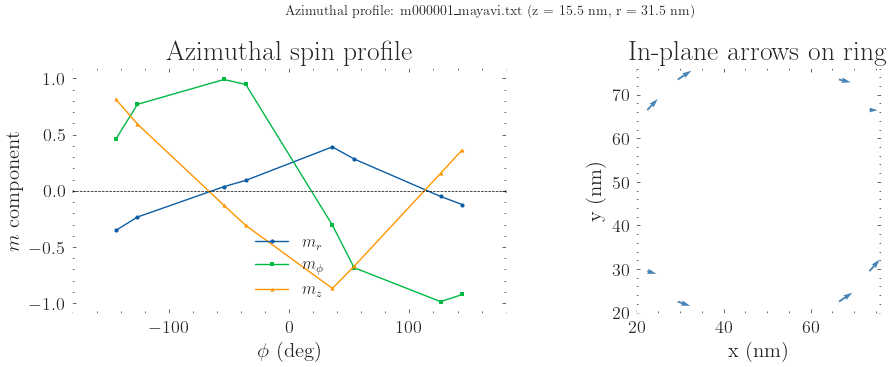

Saved azimuthal_m000001_mayavi.pdf


In [48]:
TXT_FILE = "/Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/m000001_mayavi.txt"   # ← change this

# --- Geometry (mid-shell ring) ---
R_sample = 27.0   # nm  — (R_in + R_out) / 2 of your nanotube
N_phi    = 64     # (informative only — actual points come from the grid)

# ── load ──────────────────────────────────────────────────────────────────────
data = np.loadtxt(TXT_FILE, comments='#')
x_all, y_all, z_all     = data[:, 0], data[:, 1], data[:, 2]   # nm
mx_all, my_all, mz_all  = data[:, 3], data[:, 4], data[:, 5]

# ── mid-plane z-layer ─────────────────────────────────────────────────────────
cx = (x_all.min() + x_all.max()) / 2
cy = (y_all.min() + y_all.max()) / 2

z_unique  = np.unique(z_all)
cz        = (z_unique.min() + z_unique.max()) / 2
z_mid     = z_unique[np.argmin(np.abs(z_unique - cz))]
mask_z    = np.isclose(z_all, z_mid)

x_mid, y_mid     = x_all[mask_z], y_all[mask_z]
mx_mid, my_mid, mz_mid = mx_all[mask_z], my_all[mask_z], mz_all[mask_z]

# ── radial shell closest to R_sample ─────────────────────────────────────────
r_mid     = np.sqrt((x_mid - cx)**2 + (y_mid - cy)**2)
r_unique  = np.unique(r_mid)
r_ring    = r_unique[np.argmin(np.abs(r_unique - R_sample))]
mask_ring = np.isclose(r_mid, r_ring)

x_ring  = x_mid[mask_ring]
y_ring  = y_mid[mask_ring]
mx_ring = mx_mid[mask_ring]
my_ring = my_mid[mask_ring]
mz_ring = mz_mid[mask_ring]

# sort by azimuthal angle
phi_ring = np.arctan2(y_ring - cy, x_ring - cx)
idx      = np.argsort(phi_ring)
phi_ring = phi_ring[idx]
x_ring, y_ring       = x_ring[idx], y_ring[idx]
mx_ring, my_ring, mz_ring = mx_ring[idx], my_ring[idx], mz_ring[idx]

# ── cylindrical decomposition ─────────────────────────────────────────────────
mr   =  mx_ring * np.cos(phi_ring) + my_ring * np.sin(phi_ring)
mphi = -mx_ring * np.sin(phi_ring) + my_ring * np.cos(phi_ring)

# ── plot ──────────────────────────────────────────────────────────────────────
phi_deg = np.degrees(phi_ring)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# --- left panel: component profiles ---
ax = axes[0]
ax.plot(phi_deg, mr,      'o-', ms=3, label=r'$m_r$')
ax.plot(phi_deg, mphi,    's-', ms=3, label=r'$m_\phi$')
ax.plot(phi_deg, mz_ring, '^-', ms=3, label=r'$m_z$')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(r'$\phi$ (deg)')
ax.set_ylabel(r'$m$ component')
ax.set_title('Azimuthal spin profile')
ax.set_xlim(-180, 180)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(alpha=0.25)
ax.legend(frameon=False)

# --- right panel: in-plane arrows ---
ax = axes[1]
ax.quiver(x_ring, y_ring, mx_ring, my_ring,
          scale=15, color='steelblue')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')
ax.set_title('In-plane arrows on ring')
ax.set_aspect('equal')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(alpha=0.25)

# ── suptitle & save ───────────────────────────────────────────────────────────
plt.suptitle(
    f'Azimuthal profile: {os.path.basename(TXT_FILE)}  '
    f'(z = {z_mid:.1f} nm,  r = {r_ring:.1f} nm)',
    fontsize=10,
)
plt.tight_layout()

savename = f'azimuthal_{os.path.splitext(os.path.basename(TXT_FILE))[0]}.pdf'
plt.savefig(os.path.join(PLOTS_DIR, savename), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {savename}')

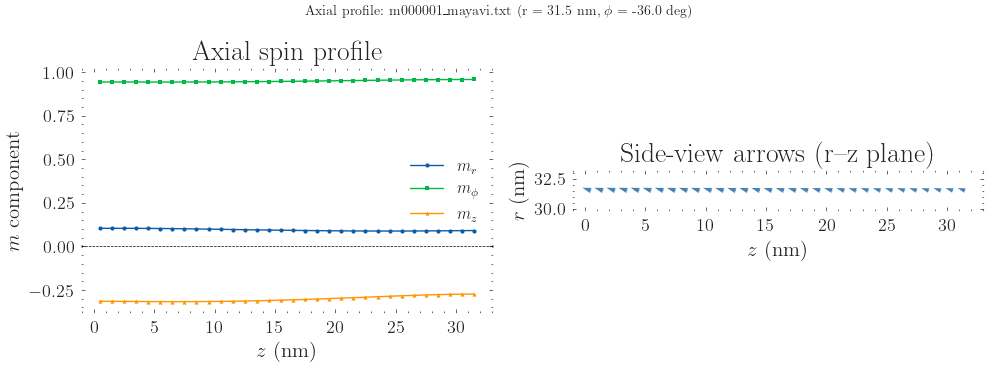

Saved axial_m000001_mayavi.pdf


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# Axial spin profile  —  single TXT file
# columns: x_nm  y_nm  z_nm  mx  my  mz
# ─────────────────────────────────────────────────────────────────────────────

# --- Point to the file you want to inspect ---
TXT_FILE = "/Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/m000001_mayavi.txt"

# --- Geometry ---
R_sample  = 27.0   # nm  — radial shell to sample (R_in + R_out) / 2
PHI_deg   = 0.0    # deg — azimuthal angle of the vertical line to sample

# ── load ──────────────────────────────────────────────────────────────────────
data = np.loadtxt(TXT_FILE, comments='#')
x_all, y_all, z_all    = data[:, 0], data[:, 1], data[:, 2]   # nm
mx_all, my_all, mz_all = data[:, 3], data[:, 4], data[:, 5]

# ── geometry centre ───────────────────────────────────────────────────────────
cx = (x_all.min() + x_all.max()) / 2
cy = (y_all.min() + y_all.max()) / 2

# ── select radial shell closest to R_sample ───────────────────────────────────
r_all    = np.sqrt((x_all - cx)**2 + (y_all - cy)**2)
r_unique = np.unique(r_all)
r_ring   = r_unique[np.argmin(np.abs(r_unique - R_sample))]
mask_r   = np.isclose(r_all, r_ring)

x_sh, y_sh, z_sh     = x_all[mask_r], y_all[mask_r], z_all[mask_r]
mx_sh, my_sh, mz_sh  = mx_all[mask_r], my_all[mask_r], mz_all[mask_r]

# ── select azimuthal column closest to PHI_deg ────────────────────────────────
phi_sh    = np.degrees(np.arctan2(y_sh - cy, x_sh - cx))   # -180..180
phi_unique = np.unique(phi_sh)
phi_pick  = phi_unique[np.argmin(np.abs(phi_unique - PHI_deg))]
mask_phi  = np.isclose(phi_sh, phi_pick)

z_col  = z_sh[mask_phi]
mx_col = mx_sh[mask_phi]
my_col = my_sh[mask_phi]
mz_col = mz_sh[mask_phi]

# sort by z
idx    = np.argsort(z_col)
z_col  = z_col[idx]
mx_col, my_col, mz_col = mx_col[idx], my_col[idx], mz_col[idx]

# ── cylindrical decomposition at fixed phi ────────────────────────────────────
phi_rad = np.radians(phi_pick)
mr_col   =  mx_col * np.cos(phi_rad) + my_col * np.sin(phi_rad)
mphi_col = -mx_col * np.sin(phi_rad) + my_col * np.cos(phi_rad)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# --- left panel: component profiles vs z ---
ax = axes[0]
ax.plot(z_col, mr_col,   'o-', ms=3, label=r'$m_r$')
ax.plot(z_col, mphi_col, 's-', ms=3, label=r'$m_\phi$')
ax.plot(z_col, mz_col,   '^-', ms=3, label=r'$m_z$')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(r'$z$ (nm)')
ax.set_ylabel(r'$m$ component')
ax.set_title('Axial spin profile')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(alpha=0.25)
ax.legend(frameon=False)

# --- right panel: side-view arrows (x-z plane) ---
ax = axes[1]
ax.quiver(z_col, np.full_like(z_col, r_ring),
          mz_col, mr_col,
          scale=15, color='steelblue')
ax.set_xlabel(r'$z$ (nm)')
ax.set_ylabel(r'$r$ (nm)')
ax.set_title('Side-view arrows (r--z plane)')
ax.set_aspect('equal')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(alpha=0.25)

# ── suptitle & save ───────────────────────────────────────────────────────────
plt.suptitle(
    f'Axial profile: {os.path.basename(TXT_FILE)}  '
    f'(r = {r_ring:.1f} nm,  $\\phi$ = {phi_pick:.1f} deg)',
    fontsize=10,
)
plt.tight_layout()

savename = f'axial_{os.path.splitext(os.path.basename(TXT_FILE))[0]}.pdf'
plt.savefig(os.path.join(PLOTS_DIR, savename), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {savename}')

### Single snapshot:

# 9. Export to read with Mayavi 

In [46]:
import os, glob
import numpy as np

# ── EDIT HERE ────────────────────────────────────────────────────────────────
SIM_DIR    = "/Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/"   # path to mumax3 .out folder
IMAGES_DIR = os.path.join(SIM_DIR, "mayavi_images") # output PNGs go here

iD = 0   # DMI index (outer loop)
iH = 0   # field index (inner loop)

# Nanotube shell (set SHELL_RADIUS_NM=None for auto-detect from data)
SHELL_RADIUS_NM = None
SHELL_OPACITY   = 0.25
SHELL_COLOR     = (0.85, 0.90, 0.82)

# Glyph
GLYPH_MODE   = 'sphere'   # 'sphere' | 'cone' | 'arrow'
SCALE_FACTOR = 0.8
COLORBY      = 'sz'       # 'sx' | 'sy' | 'sz'

# Scene
BG_COLOR  = (0.18, 0.18, 0.18)
FIG_SIZE  = (800, 800)
SAVE_SIZE = (2000, 2000)
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(IMAGES_DIR, exist_ok=True)
ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, "m*.ovf")))
print(f"SIM_DIR    : {SIM_DIR}")
print(f"IMAGES_DIR : {IMAGES_DIR}")
print(f"Snapshots  : {len(ovf_files)} .ovf files found")
if ovf_files:
    print("  First :", os.path.basename(ovf_files[0]))
    print("  Last  :", os.path.basename(ovf_files[-1]))


SIM_DIR    : /Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/
IMAGES_DIR : /Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/mayavi_images
Snapshots  : 2 .ovf files found
  First : m000000.ovf
  Last  : m000001.ovf


In [47]:
import discretisedfield as df
import numpy as np

if not ovf_files:
    raise FileNotFoundError(f"No .ovf files in {SIM_DIR}")

# snap_index: files are sorted, outer=iD inner=iH
# For a single-snapshot run (N_D=N_H=1) just use index 0.
#snap_index = iD * max(1, iH + 1) + iH
#snap_index = min(snap_index, len(ovf_files) - 1)
snap_index = 1  # override for single-snapshot cases

ovf_path = ovf_files[snap_index]
print(f"Reading  : {ovf_path}")

field = df.Field.from_file(ovf_path)
mesh  = field.mesh
print(f"Grid     : {mesh.n}")
print(f"Cell (nm): {np.array(mesh.cell)*1e9}")
print(f"Region   : {np.array(mesh.region.pmin)*1e9} → {np.array(mesh.region.pmax)*1e9} nm")

# Cell-centre coordinates in nm + magnetisation unit vectors
positions = np.array([mesh.index2point(idx) for idx in np.ndindex(*mesh.n)]) * 1e9
vectors   = field.array.reshape(-1, field.nvdim)

# Drop zero-norm cells (vacuum / outside tube)
norms = np.linalg.norm(vectors, axis=1)
mask  = norms > 0.01
pos, vec = positions[mask], vectors[mask]
print(f"Active spins (|m|>0.01): {mask.sum()} / {len(mask)}")

# Write txt
txt_path = ovf_path.replace(".ovf", "_mayavi.txt")
np.savetxt(txt_path, np.hstack([pos, vec]),
           header="x_nm  y_nm  z_nm  mx  my  mz", fmt="%.6f")
print(f"Saved    : {txt_path}")


Reading  : /Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/m000001.ovf
Grid     : [96 96 32]
Cell (nm): [1. 1. 1.]
Region   : [0. 0. 0.] → [96. 96. 32.] nm
Active spins (|m|>0.01): 65408 / 294912
Saved    : /Users/itxaso/MASTER-codi/2-TFM/mumax3/setA-Cortes-Ortuno/setA-Hrad-2.out/m000001_mayavi.txt
